# 42 — Pre-2011 backward transfer of the LSEG/Gemma continuous rule

**Question.** Does Notebook 39's calibration-portable LSEG/Gemma strategy construction
retain economic value in the earlier 2010 FNSPID regime?

**Frozen before opening 2010 returns.** The rule remains mean continuous sentiment,
cross-sectional q90−q10 dispersion at or above the 75th percentile of the strictly
prior trailing 60 XNYS sessions after 40 observations, relative breadth
`ceil(available names × 2/33)` with at least two names per leg, 25% maximum
single-name weight, gross one, dollar neutral, one open-to-open interval, and
10 bps per traded side. Late-2009 headlines supply threshold warm-up only. No
parameter is selected on 2010 returns.

The construction is directly inherited from the 888,155-headline LSEG/Gemma
portability result and translated to the separate FNSPID/FinBERT corpus exactly as
in Notebook 40. Feasibility requires at least 40 active 2010 sessions and at least
15 in each calendar half before any price return is loaded.

**Evidence status.** This is a backward external-time robustness test, not a pristine
holdout: the 574-name cohort was selected for 2011–2023 coverage and therefore
carries later-survivor conditioning. Passing evidence would strengthen the
cross-regime signal claim; it would not by itself make the strategy deployable.


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import exchange_calendars as xcals
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.panel import load_adjusted_open_prices  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.preperiod_finbert import (  # noqa: E402
    PreperiodConfig,
    ensure_events_extracted,
    ensure_finbert_scored,
    load_aggregate_signal,
)
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.trading_effectiveness import (  # noqa: E402
    benjamini_hochberg,
)

SEED = 20260815
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 9_999
RANDOM_REPLICATIONS = 999
TRAILING_SESSIONS = 60
MIN_TRAILING_SESSIONS = 40
EVENT_INTENSITY_QUANTILE = 0.75
RELATIVE_BREADTH = 2.0 / 33.0
MINIMUM_NAMES_PER_LEG = 2
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 40
MINIMUM_HALF_ACTIVE_SESSIONS = 15
WARMUP_START = pd.Timestamp("2009-10-01")
EVALUATION_START = pd.Timestamp("2010-01-01")
EVALUATION_END = pd.Timestamp("2010-12-31")

NOTEBOOK39_MANIFEST = (
    REPO_ROOT / "final_experiments/outputs/39_gemma_continuous_portability/manifest.json"
)
UPSTREAM_MANIFEST = REPO_ROOT / "reports/loop_vader_scale_20260719/manifest.json"
COHORT_PATH = REPO_ROOT / "reports/loop_vader_scale_20260719/cohort_symbols.csv"
PRICED_PANEL_PATH = (
    REPO_ROOT / "final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet"
)
PRICE_PATH = Path(
    "/Users/peterprendergast/Documents/Sentiment_Dissertation_data"
    "/FNSPID/bf9189c41527198897d1af3e17b1a0095279fc45/raw/Stock_price/full_history.zip"
)
OUTPUT_DIR = (
    REPO_ROOT
    / "final_experiments/outputs/42_fnspid_2010_preperiod_transfer"
)
CHECKPOINT_PATH = OUTPUT_DIR / "finbert_2009q4_2010_checkpoint.sqlite3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


## Bind the LSEG/Gemma rule and prepare an aggregate-only signal

This stage reads licensed FNSPID headlines locally and scores them with the cached
ProsusAI FinBERT snapshot. The raw text remains inside the gitignored resumable
SQLite checkpoint. Notebook outputs expose only aggregate counts and firm-session
scores. A current-open availability screen (never a return) is allowed here because
the established FNSPID firm-day panel applies that screen before aggregation.


In [2]:
notebook39_manifest = json.loads(NOTEBOOK39_MANIFEST.read_text())
selected_spec = notebook39_manifest["selected_future_specification"]
expected_spec = {
    "firm_open_reducer": "mean_continuous",
    "long_names": 2,
    "short_names": 2,
    "single_name_cap": 0.25,
    "gross_exposure": 1.0,
    "holding_intervals": 1,
    "cost_bps_per_side_for_future_test": 10.0,
    "current_return_window_evaluated": False,
}
for key, expected in expected_spec.items():
    if selected_spec.get(key) != expected:
        raise ValueError(f"Notebook 39 specification mismatch for {key}")
if notebook39_manifest["adaptive_schedule"] != {
    "top_bottom_names": 2,
    "trailing_sessions": 60,
    "minimum_trailing_sessions": 40,
    "event_intensity_quantile": 0.75,
}:
    raise ValueError("Notebook 39 adaptive schedule changed")

upstream_manifest = json.loads(UPSTREAM_MANIFEST.read_text())
source_records = tuple(upstream_manifest["inputs"]["news_archives"])
archive_rows = []
for record in source_records:
    path = Path(record["path"]).resolve()
    archive_rows.append((path, path.name == "nasdaq_exteral_data.csv.zst"))
archives = tuple(archive_rows)

cohort = set(pd.read_csv(COHORT_PATH, dtype=str)["symbol"].str.upper())
priced_cohort = set(
    pd.read_parquet(PRICED_PANEL_PATH, columns=["symbol"])["symbol"]
    .astype(str)
    .str.upper()
    .unique()
)
if not priced_cohort.issubset(cohort):
    raise ValueError("priced cohort is not contained in the frozen FNSPID cohort")

checkpoint_config = PreperiodConfig(
    start_session=str(WARMUP_START.date()),
    end_session=str(EVALUATION_END.date()),
)
extraction_audit = ensure_events_extracted(
    db_path=CHECKPOINT_PATH,
    archives=archives,
    source_records=source_records,
    symbols=priced_cohort,
    config=checkpoint_config,
)
scoring_audit = ensure_finbert_scored(
    db_path=CHECKPOINT_PATH,
    config=checkpoint_config,
)
signal = load_aggregate_signal(CHECKPOINT_PATH)
signal = signal.loc[signal["symbol"].isin(priced_cohort)].copy()
if signal.empty or signal["mean_continuous"].isna().any():
    raise RuntimeError("pre-period aggregate signal is empty or incomplete")
signal_before_current_open = len(signal)
availability_prices, availability_missing_symbols = load_adjusted_open_prices(
    PRICE_PATH,
    priced_cohort,
    market_symbol="SPY",
    start=str(WARMUP_START.date()),
    end=str(EVALUATION_END.date()),
)
current_open_keys = (
    availability_prices.loc[
        availability_prices["symbol"].ne("SPY"),
        ["symbol", "session_date"],
    ]
    .drop_duplicates()
)
signal = signal.merge(
    current_open_keys,
    on=["symbol", "session_date"],
    how="inner",
    validate="one_to_one",
)
signal_availability_audit = {
    "aggregate_firm_sessions_before_current_open": signal_before_current_open,
    "aggregate_firm_sessions_after_current_open": len(signal),
    "excluded_without_valid_current_open": signal_before_current_open - len(signal),
    "symbols_after_current_open": int(signal["symbol"].nunique()),
    "price_files_missing_from_known_priced_cohort": len(availability_missing_symbols),
    "price_or_return_magnitude_used_for_signal_or_gate": False,
}
del availability_prices
display(pd.DataFrame([extraction_audit]).T)
display(pd.DataFrame([scoring_audit]).T)
display(pd.DataFrame([signal_availability_audit]).T)
print(
    f"Aggregate-only signal: {len(signal):,} firm-sessions, "
    f"{signal['symbol'].nunique():,} symbols; no return computed."
)


/Users/peterprendergast/Documents/Sentiment_Dissertation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,0
completed_at,2026-08-05T20:37:27.286507+00:00
date_only_rows,2504782
deduplicated_nonempty_events,41019
exact_firm_event_duplicates,33764
firm_sessions,25252
mapped_outside_window,2435619
mapped_window_events_before_dedup,74783
maximum_session,2010-12-31
minimum_session,2009-10-01
nasdaq_timed_rows_excluded,6102


,0
batch_size,64
checkpoint_size,4096
completed_at,2026-08-05T20:39:12.827360+00:00
device,mps
events,41019
local_only,True
local_snapshot,/Users/peterprendergast/.cache/huggingface/hub...
model_id,ProsusAI/finbert
model_revision,4556d13015211d73dccd3fdd39d39232506f3e43
resumed_from,0


,0
aggregate_firm_sessions_before_current_open,25252
aggregate_firm_sessions_after_current_open,24263
excluded_without_valid_current_open,989
symbols_after_current_open,537
price_files_missing_from_known_priced_cohort,0
price_or_return_magnitude_used_for_signal_or_gate,False


Aggregate-only signal: 24,263 firm-sessions, 537 symbols; no return computed.


## Return-free feasibility gate and frozen target matrices

The adaptive threshold is evaluated on the complete XNYS session clock. Missing-news
sessions remain inactive and do not silently become observations. Only aggregate
sentiment and valid-current-open availability enter this gate; no return is computed.


In [3]:
calendar = xcals.get_calendar("XNYS", start="2009-01-01", end="2011-01-10")
calendar_sessions = pd.DatetimeIndex(
    calendar.sessions_in_range(WARMUP_START, EVALUATION_END)
).tz_localize(None)
daily_observed = (
    signal.groupby("session_date", sort=True)
    .agg(
        available_names=("symbol", "nunique"),
        q10=("mean_continuous", lambda values: float(values.quantile(0.10))),
        q90=("mean_continuous", lambda values: float(values.quantile(0.90))),
    )
    .reset_index()
)
daily_input = pd.DataFrame({"session_date": calendar_sessions}).merge(
    daily_observed,
    on="session_date",
    how="left",
    validate="one_to_one",
)
daily_input["dispersion"] = daily_input["q90"] - daily_input["q10"]
daily_input["trailing_threshold"] = (
    daily_input["dispersion"]
    .shift(1)
    .rolling(TRAILING_SESSIONS, min_periods=MIN_TRAILING_SESSIONS)
    .quantile(EVENT_INTENSITY_QUANTILE)
)
daily_input["active"] = (
    daily_input["dispersion"].notna()
    & daily_input["trailing_threshold"].notna()
    & daily_input["dispersion"].ge(daily_input["trailing_threshold"])
)
daily_input["names_per_leg"] = 0
has_breadth = daily_input["available_names"].fillna(0).ge(
    2 * MINIMUM_NAMES_PER_LEG
)
daily_input.loc[has_breadth, "names_per_leg"] = np.maximum(
    MINIMUM_NAMES_PER_LEG,
    np.ceil(
        daily_input.loc[has_breadth, "available_names"] * RELATIVE_BREADTH
    ).astype(int),
)
if (
    2 * daily_input["names_per_leg"]
    > daily_input["available_names"].fillna(0)
).any():
    raise RuntimeError("translated breadth creates overlapping legs")
daily_input["period"] = np.where(
    daily_input["session_date"].lt(EVALUATION_START),
    "warmup",
    "evaluation",
)

evaluation_sessions = pd.DatetimeIndex(
    daily_input.loc[daily_input["period"].eq("evaluation"), "session_date"]
)
evaluation_midpoint = pd.Timestamp(
    evaluation_sessions[len(evaluation_sessions) // 2]
)
feasibility = pd.DataFrame(
    [
        {
            "warmup_sessions": int(daily_input["period"].eq("warmup").sum()),
            "evaluation_sessions": len(evaluation_sessions),
            "warmup_observed_sessions": int(
                daily_input.eval("period == 'warmup' and dispersion == dispersion").sum()
            ),
            "evaluation_observed_sessions": int(
                daily_input.eval(
                    "period == 'evaluation' and dispersion == dispersion"
                ).sum()
            ),
            "evaluation_active": int(
                daily_input.eval("period == 'evaluation' and active").sum()
            ),
            "evaluation_first_half_active": int(
                (
                    daily_input["period"].eq("evaluation")
                    & daily_input["session_date"].lt(evaluation_midpoint)
                    & daily_input["active"]
                ).sum()
            ),
            "evaluation_second_half_active": int(
                (
                    daily_input["period"].eq("evaluation")
                    & daily_input["session_date"].ge(evaluation_midpoint)
                    & daily_input["active"]
                ).sum()
            ),
            "minimum_available_names_on_observed_dates": int(
                daily_input["available_names"].dropna().min()
            ),
            "median_available_names_on_observed_dates": float(
                daily_input["available_names"].dropna().median()
            ),
            "evaluation_midpoint": evaluation_midpoint,
        }
    ]
)
feasibility_gate = bool(
    feasibility.loc[0, "evaluation_active"] >= MINIMUM_ACTIVE_SESSIONS
    and feasibility.loc[0, "evaluation_first_half_active"]
    >= MINIMUM_HALF_ACTIVE_SESSIONS
    and feasibility.loc[0, "evaluation_second_half_active"]
    >= MINIMUM_HALF_ACTIVE_SESSIONS
)
daily_input.to_csv(OUTPUT_DIR / "input_schedule.csv", index=False)
feasibility.to_csv(OUTPUT_DIR / "feasibility.csv", index=False)
display(feasibility.T)
if not feasibility_gate:
    raise RuntimeError(
        "return-free pre-period feasibility gate failed; 2010 outcomes remain unopened"
    )

symbols = tuple(sorted(signal["symbol"].unique()))
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
session_index = {
    session: index for index, session in enumerate(evaluation_sessions)
}
rank_weights = np.zeros(
    (len(evaluation_sessions), len(symbols)), dtype=float
)
availability = np.zeros_like(rank_weights, dtype=bool)
breadth_by_session = np.zeros(len(evaluation_sessions), dtype=int)
input_lookup = daily_input.set_index("session_date")

evaluation_signal = signal.loc[
    signal["session_date"].between(EVALUATION_START, EVALUATION_END)
]
for session, day in evaluation_signal.groupby("session_date", sort=True):
    session = pd.Timestamp(session)
    row_index = session_index[session]
    ordered = day.sort_values(
        ["mean_continuous", "symbol"],
        ascending=[True, True],
        kind="mergesort",
    )
    available_indices = np.array(
        [symbol_index[str(symbol)] for symbol in ordered["symbol"]],
        dtype=int,
    )
    availability[row_index, available_indices] = True
    names_per_leg = int(input_lookup.loc[session, "names_per_leg"])
    breadth_by_session[row_index] = names_per_leg
    if names_per_leg == 0:
        continue
    short_indices = available_indices[:names_per_leg]
    long_indices = available_indices[-names_per_leg:]
    rank_weights[row_index, long_indices] = 0.5 / names_per_leg
    rank_weights[row_index, short_indices] = -0.5 / names_per_leg

active_flag = (
    input_lookup.reindex(evaluation_sessions)["active"].fillna(False).to_numpy(bool)
)
gated_weights = rank_weights * active_flag[:, None]
if float(np.abs(gated_weights).max()) > SINGLE_NAME_CAP + 1e-12:
    raise RuntimeError("frozen target exceeds the 25% name cap")
print("Return-free gate passed; frozen 2010 targets are now fixed.")


,0
warmup_sessions,64
evaluation_sessions,252
warmup_observed_sessions,64
evaluation_observed_sessions,252
evaluation_active,59
evaluation_first_half_active,30
evaluation_second_half_active,29
minimum_available_names_on_observed_dates,9
median_available_names_on_observed_dates,78.000000
evaluation_midpoint,2010-07-06 00:00:00


Return-free gate passed; frozen 2010 targets are now fixed.


## Open 2010 adjusted-open outcomes once

The return convention is the same split-adjusted open-to-open simple return used in
Notebook 40. Missing selected returns force the entire session to cash; no return is
imputed or treated as zero for an active position.


In [4]:
next_evaluation_sessions = pd.DatetimeIndex(
    [calendar.next_session(session) for session in evaluation_sessions]
).tz_localize(None)
prices, missing_price_symbols = load_adjusted_open_prices(
    PRICE_PATH,
    set(symbols),
    market_symbol="SPY",
    start=str(EVALUATION_START.date()),
    end=str((next_evaluation_sessions.max() + pd.Timedelta(days=1)).date()),
)
prices["symbol"] = prices["symbol"].astype(str).str.upper()
price_wide = prices.pivot(
    index="session_date", columns="symbol", values="adjusted_open"
)
current_open = price_wide.reindex(
    index=evaluation_sessions, columns=symbols
).to_numpy(dtype=float)
next_open = price_wide.reindex(
    index=next_evaluation_sessions, columns=symbols
).to_numpy(dtype=float)
return_matrix = next_open / current_open - 1.0

prepolicy_selected = ~np.isclose(rank_weights, 0.0)
missing_selected = prepolicy_selected & ~np.isfinite(return_matrix)
affected_indices = (
    np.unique(np.argwhere(missing_selected)[:, 0])
    if missing_selected.any()
    else np.array([], dtype=int)
)
outcome_availability_audit = pd.DataFrame(
    [
        {
            "cohort_symbols_without_price_file": len(missing_price_symbols),
            "missing_returns_in_signal_panel": int(
                (availability & ~np.isfinite(return_matrix)).sum()
            ),
            "missing_frozen_selected_positions": int(missing_selected.sum()),
            "affected_sessions": len(affected_indices),
            "affected_session_dates": "|".join(
                str(evaluation_sessions[index].date())
                for index in affected_indices
            ),
            "policy": "fail closed to cash for the complete affected session",
        }
    ]
)
rank_weights[affected_indices] = 0.0
gated_weights[affected_indices] = 0.0
active_flag[affected_indices] = False
if not np.isfinite(return_matrix[~np.isclose(rank_weights, 0.0)]).all():
    raise RuntimeError("fail-closed missing-return policy is incomplete")
safe_returns = np.where(np.isfinite(return_matrix), return_matrix, 0.0)

spy_open = price_wide["SPY"]
spy_returns = (
    spy_open.reindex(next_evaluation_sessions).to_numpy(dtype=float)
    / spy_open.reindex(evaluation_sessions).to_numpy(dtype=float)
    - 1.0
)
news_market_returns = np.array(
    [
        np.nanmean(np.where(available, returns, np.nan))
        if available.any()
        else np.nan
        for available, returns in zip(availability, return_matrix, strict=True)
    ]
)
factor_panel = pd.DataFrame(
    {
        "session_date": evaluation_sessions,
        "spy_return": spy_returns,
        "equal_weight_news_market": news_market_returns,
    }
)
display(outcome_availability_audit.T)


/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_8376/3060102277.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end=str((next_evaluation_sessions.max() + pd.Timedelta(days=1)).date()),


,0
cohort_symbols_without_price_file,0
missing_returns_in_signal_panel,0
missing_frozen_selected_positions,0
affected_sessions,0
affected_session_dates,
policy,fail closed to cash for the complete affected ...


In [5]:
def matrix_backtest(
    weights: np.ndarray,
    returns: np.ndarray,
    decision_sessions: pd.DatetimeIndex,
    return_end_sessions: pd.DatetimeIndex,
    *,
    cost_bps: float,
) -> pd.DataFrame:
    if weights.shape != returns.shape or weights.shape[0] != len(decision_sessions):
        raise ValueError("matrix backtest inputs do not align")
    current = np.zeros(weights.shape[1], dtype=float)
    gross_rows = []
    net_rows = []
    turnover_rows = []
    cost_rows = []
    gross_exposure_rows = []
    active_name_rows = []
    rate = cost_bps / 10_000.0
    for target, asset_returns in zip(weights, returns, strict=True):
        if not np.isfinite(asset_returns[~np.isclose(target, 0.0)]).all():
            raise RuntimeError("active target has a missing return")
        asset_returns = np.where(np.isfinite(asset_returns), asset_returns, 0.0)
        turnover = float(np.abs(target - current).sum())
        cost = rate * turnover
        gross = float(np.dot(target, asset_returns))
        net = gross - cost
        if 1.0 + net <= 0:
            raise RuntimeError("strategy NAV became non-positive")
        current = target * (1.0 + asset_returns) / (1.0 + net)
        gross_rows.append(gross)
        net_rows.append(net)
        turnover_rows.append(turnover)
        cost_rows.append(cost)
        gross_exposure_rows.append(float(np.abs(target).sum()))
        active_name_rows.append(int(np.count_nonzero(target)))
    liquidation_turnover = float(np.abs(current).sum())
    liquidation_cost = rate * liquidation_turnover
    net_rows[-1] = (1.0 + net_rows[-1]) * (1.0 - liquidation_cost) - 1.0
    turnover_rows[-1] += liquidation_turnover
    cost_rows[-1] += liquidation_cost
    return pd.DataFrame(
        {
            "session_date": decision_sessions,
            "next_session": return_end_sessions,
            "gross_return": gross_rows,
            "net_return": net_rows,
            "turnover": turnover_rows,
            "cost": cost_rows,
            "gross_exposure": gross_exposure_rows,
            "active_names": active_name_rows,
        }
    )


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * np.sqrt(252)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": (
            float(10_000.0 * gross.sum() / turnover)
            if turnover > 0
            else float("nan")
        ),
        "cost_bps_per_side": cost_bps,
    }


## Frozen performance, costs, and stability


In [6]:
daily_paths = {}
strategy_rows = []
for strategy_name, weights in (
    ("adaptive_dispersion", gated_weights),
    ("always_active_rank", rank_weights),
):
    daily = matrix_backtest(
        weights,
        safe_returns,
        evaluation_sessions,
        next_evaluation_sessions,
        cost_bps=COST_BPS,
    )
    daily_paths[strategy_name] = daily
    strategy_rows.append(
        {
            "strategy": strategy_name,
            **summarize(daily, cost_bps=COST_BPS),
        }
    )
strategy_results = pd.DataFrame(strategy_rows)

cost_rows = []
for cost_bps in COST_GRID:
    daily = matrix_backtest(
        gated_weights,
        safe_returns,
        evaluation_sessions,
        next_evaluation_sessions,
        cost_bps=cost_bps,
    )
    cost_rows.append(summarize(daily, cost_bps=cost_bps))
cost_curve = pd.DataFrame(cost_rows)

evaluation_daily = daily_paths["adaptive_dispersion"]
half_rows = []
for half_name, mask in (
    ("first_half", evaluation_daily["session_date"].lt(evaluation_midpoint)),
    ("second_half", evaluation_daily["session_date"].ge(evaluation_midpoint)),
):
    half_rows.append(
        {
            "period": half_name,
            **summarize(
                evaluation_daily.loc[mask].reset_index(drop=True),
                cost_bps=COST_BPS,
            ),
        }
    )
evaluation_halves = pd.DataFrame(half_rows)
display(strategy_results)
display(cost_curve)
display(evaluation_halves)


,strategy,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,adaptive_dispersion,252,59,-0.000221,-0.000681,-1.140539,-3.396953,0.050491,-0.055253,-0.158735,-0.166434,0.459807,115.871410,-4.802196,10.000000
1,always_active_rank,252,252,0.000088,-0.001849,0.241652,-5.082591,0.091660,0.018110,-0.375312,-0.383064,1.936488,487.995019,0.453330,10.000000


,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,252,59,-0.000221,-0.000221,-1.140539,-1.140539,0.048787,-0.055253,-0.055253,-0.080907,0.459513,115.797341,-4.805267,0.000000
1,252,59,-0.000221,-0.000267,-1.140539,-1.375442,0.048875,-0.055253,-0.066137,-0.088414,0.459543,115.804736,-4.804960,1.000000
2,252,59,-0.000221,-0.000313,-1.140539,-1.608918,0.048981,-0.055253,-0.076899,-0.096808,0.459572,115.812135,-4.804653,2.000000
3,252,59,-0.000221,-0.000451,-1.140539,-2.298280,0.049411,-0.055253,-0.108461,-0.123109,0.459660,115.834344,-4.803732,5.000000
4,252,59,-0.000221,-0.000681,-1.140539,-3.396953,0.050491,-0.055253,-0.158735,-0.166434,0.459807,115.871410,-4.802196,10.000000


,period,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,126,30,-0.000312,-0.000771,-1.374086,-3.296859,0.058941,-0.039332,-0.093409,-0.104502,0.459157,57.853816,-6.794100,10.000000
1,second_half,126,29,-0.000130,-0.000590,-0.843062,-3.671188,0.040507,-0.016573,-0.072057,-0.076014,0.460457,58.017594,-2.815914,10.000000


## Cash, timing, and conditional-name inference

Cash inference uses a circular five-session block bootstrap. The mechanism family
contains exactly two one-sided randomisation tests: circularly shifted dispersion
timing and random long/short names conditional on the same active sessions and
breadth. Their p-values receive BH correction as frozen in Notebook 40.


In [7]:
cash = evaluation_daily[["session_date"]].copy()
cash["net_return"] = 0.0
cash_result = paired_block_bootstrap_difference(
    evaluation_daily,
    cash,
    value_col="net_return",
    block_length=BLOCK_LENGTH,
    replications=BOOTSTRAP_REPLICATIONS,
    seed=SEED,
)
always_result = paired_block_bootstrap_difference(
    evaluation_daily,
    daily_paths["always_active_rank"],
    value_col="net_return",
    block_length=BLOCK_LENGTH,
    replications=BOOTSTRAP_REPLICATIONS,
    seed=SEED + 1,
)
inference = pd.DataFrame(
    [
        {"comparison": "adaptive_minus_cash", **cash_result},
        {"comparison": "adaptive_minus_always_active", **always_result},
    ]
)

observed = strategy_results.set_index("strategy").loc["adaptive_dispersion"]
timing_rows = []
for shift in range(1, len(evaluation_sessions)):
    shifted_active = np.roll(active_flag, shift)
    shifted_weights = rank_weights * shifted_active[:, None]
    shifted_daily = matrix_backtest(
        shifted_weights,
        safe_returns,
        evaluation_sessions,
        next_evaluation_sessions,
        cost_bps=COST_BPS,
    )
    shifted_summary = summarize(shifted_daily, cost_bps=COST_BPS)
    timing_rows.append(
        {
            "shift": shift,
            "mean_net": shifted_summary["mean_net"],
            "sharpe_net": shifted_summary["sharpe_net"],
        }
    )
timing_null = pd.DataFrame(timing_rows)
timing_p = float(
    (1 + timing_null["mean_net"].ge(observed["mean_net"]).sum())
    / (1 + len(timing_null))
)

rng = np.random.default_rng(SEED)
name_rows = []
for replication in range(RANDOM_REPLICATIONS):
    random_weights = np.zeros_like(gated_weights)
    for row_index in np.flatnonzero(active_flag):
        available_indices = np.flatnonzero(availability[row_index])
        names_per_leg = int(breadth_by_session[row_index])
        if len(available_indices) < 2 * names_per_leg:
            continue
        permutation = rng.permutation(available_indices)
        long_indices = permutation[:names_per_leg]
        short_indices = permutation[names_per_leg : 2 * names_per_leg]
        random_weights[row_index, long_indices] = 0.5 / names_per_leg
        random_weights[row_index, short_indices] = -0.5 / names_per_leg
    random_daily = matrix_backtest(
        random_weights,
        safe_returns,
        evaluation_sessions,
        next_evaluation_sessions,
        cost_bps=COST_BPS,
    )
    random_summary = summarize(random_daily, cost_bps=COST_BPS)
    name_rows.append(
        {
            "replication": replication,
            "mean_net": random_summary["mean_net"],
            "sharpe_net": random_summary["sharpe_net"],
        }
    )
name_null = pd.DataFrame(name_rows)
name_p = float(
    (1 + name_null["mean_net"].ge(observed["mean_net"]).sum())
    / (1 + len(name_null))
)
mechanism_q = benjamini_hochberg([timing_p, name_p])
mechanism_inference = pd.DataFrame(
    [
        {
            "test": "dispersion_timing_shift",
            "observed_mean_net": observed["mean_net"],
            "null_mean_net": float(timing_null["mean_net"].mean()),
            "observed_minus_null_bps_session": float(
                (observed["mean_net"] - timing_null["mean_net"].mean()) * 10_000
            ),
            "p_one_sided": timing_p,
            "q_bh": mechanism_q[0],
        },
        {
            "test": "conditional_random_names",
            "observed_mean_net": observed["mean_net"],
            "null_mean_net": float(name_null["mean_net"].mean()),
            "observed_minus_null_bps_session": float(
                (observed["mean_net"] - name_null["mean_net"].mean()) * 10_000
            ),
            "p_one_sided": name_p,
            "q_bh": mechanism_q[1],
        },
    ]
)
display(inference)
display(mechanism_inference)


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,adaptive_minus_cash,252,-0.000681,-0.001109,-0.000282,0.001100,5,9999,20260815
1,adaptive_minus_always_active,252,0.001168,0.000574,0.001781,0.000200,5,9999,20260816


,test,observed_mean_net,null_mean_net,observed_minus_null_bps_session,p_one_sided,q_bh
0,dispersion_timing_shift,-0.000681,-0.000443,-2.380993,0.968254,0.968254
1,conditional_random_names,-0.000681,-0.000461,-2.200531,0.897000,0.968254


## Factor control, contribution concentration, and frozen gates


In [8]:
regression = evaluation_daily[["session_date", "net_return"]].merge(
    factor_panel,
    on="session_date",
    validate="one_to_one",
).dropna()
factor_specs = {
    "constant_only": [],
    "spy_only": ["spy_return"],
    "spy_plus_news_market": ["spy_return", "equal_weight_news_market"],
}
factor_rows = []
for model_name, columns in factor_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "spy_beta": float(fit.params.get("spy_return", float("nan"))),
            "news_market_beta": float(
                fit.params.get("equal_weight_news_market", float("nan"))
            ),
        }
    )
factor_models = pd.DataFrame(factor_rows)

gross_contributions = gated_weights * safe_returns
symbol_gross = pd.DataFrame(
    {
        "symbol": symbols,
        "gross_contribution": gross_contributions.sum(axis=0),
        "absolute_gross_contribution": np.abs(gross_contributions).sum(axis=0),
    }
)
absolute_total = float(symbol_gross["absolute_gross_contribution"].sum())
concentration = pd.DataFrame(
    [
        {
            "symbols_in_signal": len(symbols),
            "symbols_ever_active": int(
                np.any(~np.isclose(gated_weights, 0.0), axis=0).sum()
            ),
            "mean_active_names": float(
                np.count_nonzero(gated_weights, axis=1)[active_flag].mean()
            ),
            "maximum_name_weight": float(np.abs(gated_weights).max()),
            "absolute_contribution_hhi": (
                float(
                    np.square(
                        symbol_gross["absolute_gross_contribution"] / absolute_total
                    ).sum()
                )
                if absolute_total > 0
                else float("nan")
            ),
        }
    ]
)

cash_eval = inference.set_index("comparison").loc["adaptive_minus_cash"]
half_lookup = evaluation_halves.set_index("period")
factor_eval = factor_models.set_index("model").loc["spy_plus_news_market"]
outcome_feasibility_gate = bool(active_flag.sum() >= MINIMUM_ACTIVE_SESSIONS)
cash_gate = bool(
    observed["sharpe_net"] > 0
    and observed["breakeven_bps_per_side"] > COST_BPS
    and cash_eval["ci_low"] > 0
    and cash_eval["p_two_sided"] < 0.05
    and half_lookup.loc["first_half", "sharpe_net"] >= 0
    and half_lookup.loc["second_half", "sharpe_net"] >= 0
)
mechanism_gate = bool(
    mechanism_inference["q_bh"].lt(0.05).all()
    and mechanism_inference["observed_minus_null_bps_session"].gt(0).all()
)
factor_alpha_gate = bool(
    factor_eval["alpha_ci_low_bps_session"] > 0
    and factor_eval["alpha_p_two_sided_hac5"] < 0.05
)
replication_gate = bool(
    feasibility_gate
    and outcome_feasibility_gate
    and cash_gate
    and mechanism_gate
    and factor_alpha_gate
)
gates = pd.DataFrame(
    [
        {
            "return_free_feasibility_gate": feasibility_gate,
            "post_availability_feasibility_gate": outcome_feasibility_gate,
            "cash_and_stability_gate": cash_gate,
            "mechanism_gate": mechanism_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "replication_gate": replication_gate,
            "gross_sharpe": float(observed["sharpe_gross"]),
            "net_sharpe_10bps": float(observed["sharpe_net"]),
            "breakeven_bps_per_side": float(observed["breakeven_bps_per_side"]),
            "cash_ci_low_bps_session": float(cash_eval["ci_low"] * 10_000),
            "cash_ci_high_bps_session": float(cash_eval["ci_high"] * 10_000),
            "cash_p_two_sided": float(cash_eval["p_two_sided"]),
            "timing_q_bh": float(
                mechanism_inference.set_index("test").loc[
                    "dispersion_timing_shift", "q_bh"
                ]
            ),
            "name_selection_q_bh": float(
                mechanism_inference.set_index("test").loc[
                    "conditional_random_names", "q_bh"
                ]
            ),
            "factor_alpha_bps_session": float(factor_eval["alpha_bps_session"]),
            "factor_alpha_ci_low_bps_session": float(
                factor_eval["alpha_ci_low_bps_session"]
            ),
            "factor_alpha_p_two_sided": float(
                factor_eval["alpha_p_two_sided_hac5"]
            ),
        }
    ]
)
display(factor_models)
display(concentration.T)
display(gates.T)


,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,spy_beta,news_market_beta
0,constant_only,252,0,-6.806156,-10.971680,-2.640632,-3.202435,0.001363,0.000000,NaN,NaN
1,spy_only,252,1,-6.594350,-10.681006,-2.507693,-3.162656,0.001563,0.013958,-0.034564,NaN
2,spy_plus_news_market,252,2,-6.519062,-10.634192,-2.403932,-3.104914,0.001903,0.018271,0.038216,-0.063419


,0
symbols_in_signal,537.000000
symbols_ever_active,315.000000
mean_active_names,11.288136
maximum_name_weight,0.166667
absolute_contribution_hhi,0.006300


,0
return_free_feasibility_gate,True
post_availability_feasibility_gate,True
cash_and_stability_gate,False
mechanism_gate,False
factor_alpha_gate,False
replication_gate,False
gross_sharpe,-1.140539
net_sharpe_10bps,-3.396953
breakeven_bps_per_side,-4.802196
cash_ci_low_bps_session,-11.093982


## Figures


findfont: Failed to find font weight medium, now using 400.


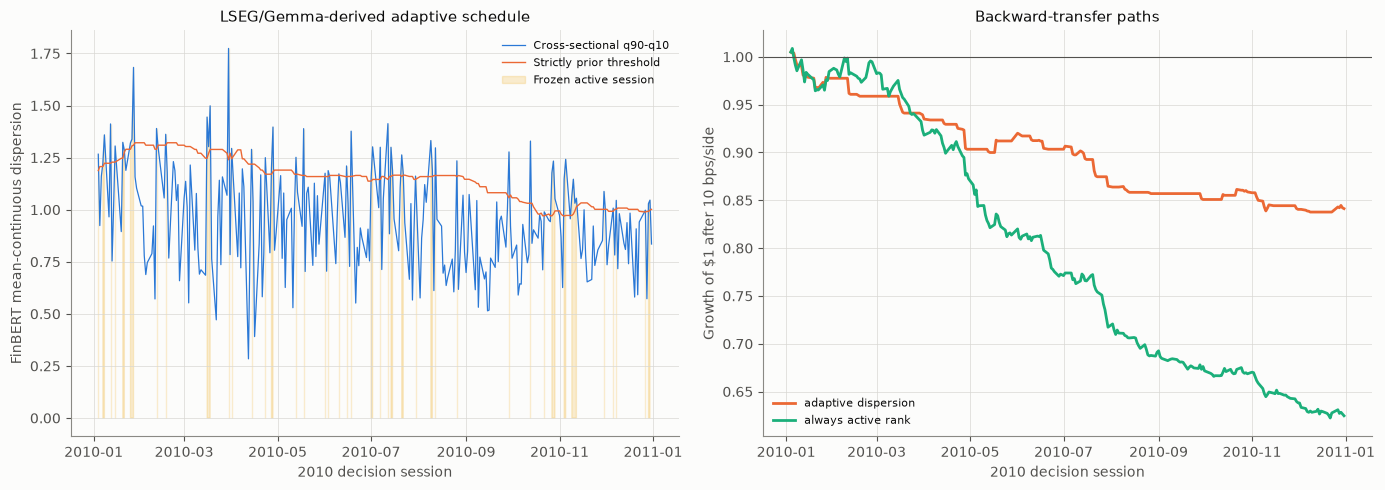

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
use = daily_input.loc[daily_input["period"].eq("evaluation")]
axes[0].plot(
    use["session_date"],
    use["dispersion"],
    color=CATEGORICAL[0],
    linewidth=0.9,
    label="Cross-sectional q90-q10",
)
axes[0].plot(
    use["session_date"],
    use["trailing_threshold"],
    color=CATEGORICAL[1],
    linewidth=1.0,
    label="Strictly prior threshold",
)
axes[0].fill_between(
    use["session_date"],
    0,
    use["dispersion"],
    where=use["active"],
    color=CATEGORICAL[3],
    alpha=0.18,
    label="Frozen active session",
)
axes[0].set_xlabel("2010 decision session")
axes[0].set_ylabel("FinBERT mean-continuous dispersion")
axes[0].set_title("LSEG/Gemma-derived adaptive schedule")
axes[0].legend(loc="best", fontsize=8)

for strategy_name, colour in (
    ("adaptive_dispersion", CATEGORICAL[1]),
    ("always_active_rank", CATEGORICAL[2]),
):
    daily = daily_paths[strategy_name]
    axes[1].plot(
        daily["session_date"],
        np.cumprod(1.0 + daily["net_return"]),
        color=colour,
        label=strategy_name.replace("_", " "),
    )
axes[1].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("2010 decision session")
axes[1].set_ylabel("Growth of $1 after 10 bps/side")
axes[1].set_title("Backward-transfer paths")
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "schedule_and_paths.png", dpi=170, bbox_inches="tight")
plt.show()


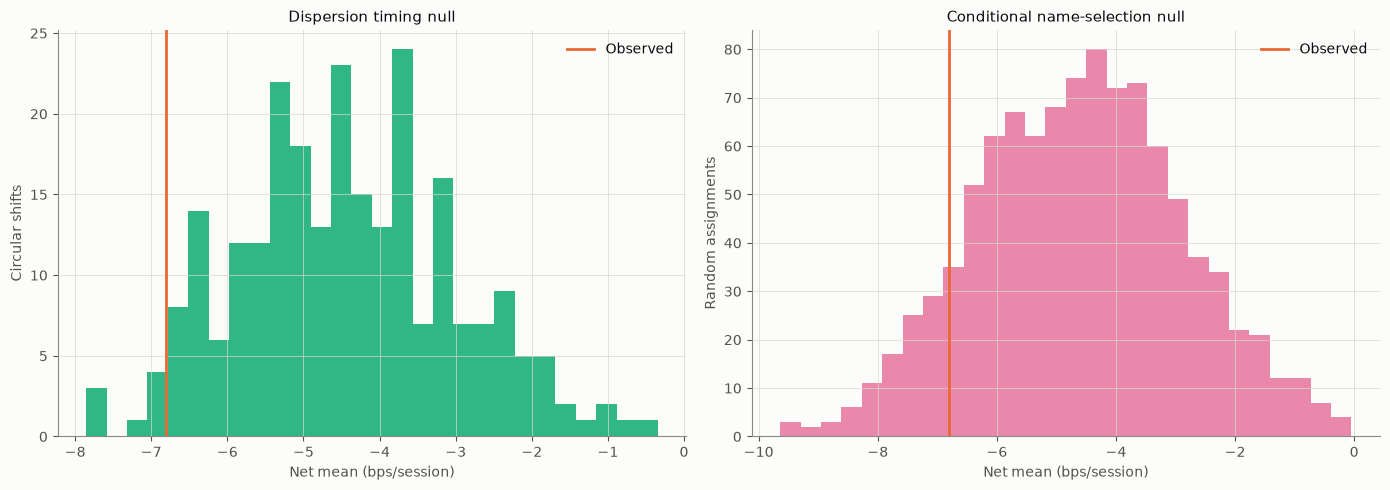

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].hist(
    timing_null["mean_net"] * 10_000,
    bins=28,
    color=CATEGORICAL[2],
    alpha=0.9,
)
axes[0].axvline(
    observed["mean_net"] * 10_000,
    color=CATEGORICAL[1],
    linewidth=2,
    label="Observed",
)
axes[0].set_xlabel("Net mean (bps/session)")
axes[0].set_ylabel("Circular shifts")
axes[0].set_title("Dispersion timing null")
axes[0].legend(loc="best")

axes[1].hist(
    name_null["mean_net"] * 10_000,
    bins=28,
    color=CATEGORICAL[4],
    alpha=0.9,
)
axes[1].axvline(
    observed["mean_net"] * 10_000,
    color=CATEGORICAL[1],
    linewidth=2,
    label="Observed",
)
axes[1].set_xlabel("Net mean (bps/session)")
axes[1].set_ylabel("Random assignments")
axes[1].set_title("Conditional name-selection null")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mechanism_nulls.png", dpi=170, bbox_inches="tight")
plt.show()


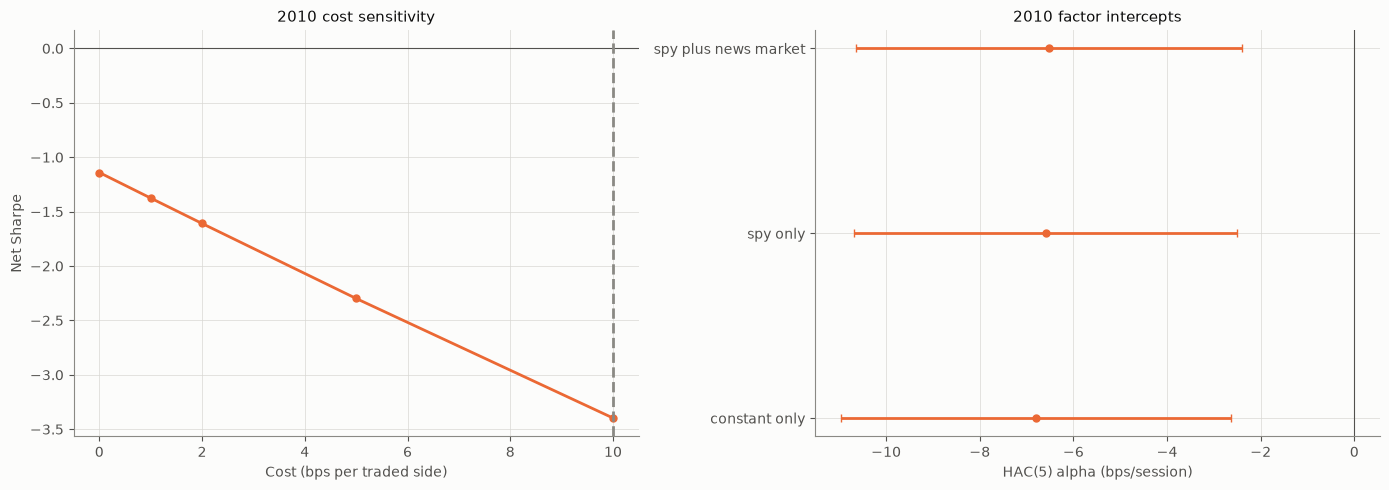

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
axes[0].plot(
    cost_curve["cost_bps_per_side"],
    cost_curve["sharpe_net"],
    marker="o",
    color=CATEGORICAL[1],
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("2010 cost sensitivity")

y = np.arange(len(factor_models))
axes[1].errorbar(
    factor_models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            factor_models["alpha_bps_session"]
            - factor_models["alpha_ci_low_bps_session"],
            factor_models["alpha_ci_high_bps_session"]
            - factor_models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=3,
)
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_yticks(y, factor_models["model"].str.replace("_", " "))
axes[1].set_xlabel("HAC(5) alpha (bps/session)")
axes[1].set_title("2010 factor intercepts")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "costs_and_factor_alpha.png", dpi=170, bbox_inches="tight")
plt.show()


## Persist aggregate evidence


In [12]:
outcome_availability_audit.to_csv(
    OUTPUT_DIR / "outcome_availability_audit.csv", index=False
)
pd.DataFrame([signal_availability_audit]).to_csv(
    OUTPUT_DIR / "signal_availability_audit.csv", index=False
)
strategy_results.to_csv(OUTPUT_DIR / "strategy_results.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
evaluation_halves.to_csv(OUTPUT_DIR / "evaluation_halves.csv", index=False)
timing_null.to_csv(OUTPUT_DIR / "timing_null.csv", index=False)
name_null.to_csv(OUTPUT_DIR / "conditional_name_null.csv", index=False)
mechanism_inference.to_csv(OUTPUT_DIR / "mechanism_inference.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
symbol_gross.to_csv(OUTPUT_DIR / "symbol_gross_contributions.csv", index=False)
concentration.to_csv(OUTPUT_DIR / "concentration.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for strategy_name, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{strategy_name}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "BACKWARD_EXTERNAL_TIME_LSEG_GEMMA_RULE_TRANSFER",
    "notebook": "42_fnspid_2010_preperiod_transfer.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "notebook39_manifest": str(NOTEBOOK39_MANIFEST.relative_to(REPO_ROOT)),
        "notebook39_manifest_sha256": sha256_file(NOTEBOOK39_MANIFEST),
        "upstream_frozen_manifest": str(UPSTREAM_MANIFEST.relative_to(REPO_ROOT)),
        "upstream_frozen_manifest_sha256": sha256_file(UPSTREAM_MANIFEST),
        "cohort_path": str(COHORT_PATH.relative_to(REPO_ROOT)),
        "cohort_sha256": sha256_file(COHORT_PATH),
        "checkpoint_path": str(CHECKPOINT_PATH.relative_to(REPO_ROOT)),
        "checkpoint_sha256": sha256_file(CHECKPOINT_PATH),
        "checkpoint_is_gitignored": True,
        "licensed_headline_text_emitted": False,
        "lseg_gemma_return_loaded": False,
        "current_open_availability_screen_before_gate": True,
        "return_magnitude_computed_before_gate": False,
        "fnspid_2010_return_opened_after_input_gate": True,
        "extraction_audit": extraction_audit,
        "scoring_audit": scoring_audit,
        "signal_availability_audit": signal_availability_audit,
    },
    "translation": {
        "rule_origin": "Notebook 39 complete LSEG/Gemma 26B continuous portability result",
        "uses_lseg_gemma_signal_design": True,
        "scorer_in_2010": "ProsusAI/finbert local cached snapshot",
        "warmup": "2009-10-01 through 2009-12-31 inputs only",
        "outcome_window": "2010-01-01 through 2010-12-31 decision sessions",
        "universe": "later-selected coherent FNSPID cohort with a valid current adjusted open on the decision session",
        "breadth": "ceil(available names * 2/33), minimum two per leg",
        "signal": "mean continuous signed probability score",
        "direction": "positive long, negative short",
        "gross_exposure": 1.0,
        "single_name_cap": SINGLE_NAME_CAP,
        "holding_intervals": 1,
        "cost_bps_per_side": COST_BPS,
        "missing_return_policy": "complete selected session forced to cash",
        "accounting": "drift-aware open-to-open with terminal liquidation",
    },
    "frozen_gates": {
        "return_free_feasibility": (
            "at least 40 active 2010 sessions and at least 15 in each calendar half"
        ),
        "cash_and_stability": (
            "net Sharpe > 0, break-even > 10 bps, cash CI low > 0, "
            "cash p < 0.05, and both half Sharpes >= 0"
        ),
        "mechanism": "both timing and conditional-name BH q < 0.05 with positive effects",
        "factor_alpha": "SPY-plus-news-market HAC(5) intercept CI low > 0 and p < 0.05",
    },
    "feasibility": json.loads(
        feasibility.to_json(orient="records", date_format="iso")
    )[0],
    "outcome_availability_audit": json.loads(
        outcome_availability_audit.to_json(orient="records")
    )[0],
    "strategy_results": json.loads(strategy_results.to_json(orient="records")),
    "cost_curve": json.loads(cost_curve.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records")),
    "evaluation_halves": json.loads(
        evaluation_halves.to_json(orient="records")
    ),
    "mechanism_inference": json.loads(
        mechanism_inference.to_json(orient="records")
    ),
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "concentration": json.loads(concentration.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "invalidation_history": [
        {
            "run": "invalidated_v1_file_level_price_filter",
            "reason": (
                "used has-price-file rather than valid-current-open firm-day "
                "eligibility, unlike the established FNSPID panel; this admitted "
                "later IPOs and forced 95 sessions to cash"
            ),
            "preserved_under": (
                "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/"
                "invalidated_v1_file_level_price_filter"
            ),
            "outcome_used_to_choose_repair": False,
        }
    ],
    "limitations": [
        "the 2010 cohort is conditioned on later 2011-2023 news coverage and is subject to survivor selection",
        "this is backward external-time evidence rather than a pristine prospective holdout",
        "FNSPID uses FinBERT rather than Gemma, so this tests construction transfer rather than scorer identity",
        "FNSPID date-only news uses the conservative strictly-next-session mapping",
        "prices are split adjusted but not dividend adjusted",
        "borrow fees, variable spreads, impact, and intraday microstructure are omitted",
        "circular shifts assume approximate stationarity and wrap endpoints",
        "the one-year sample is materially shorter than the primary 2011-2023 spine",
        "passing gates would not alone justify live deployment",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))


{
  "status": "BACKWARD_EXTERNAL_TIME_LSEG_GEMMA_RULE_TRANSFER",
  "notebook": "42_fnspid_2010_preperiod_transfer.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260815,
  "input": {
    "notebook39_manifest": "final_experiments/outputs/39_gemma_continuous_portability/manifest.json",
    "notebook39_manifest_sha256": "f24bff1a8ef71c1f7296c0bee3eba5a3ec4c2adde1bf7b8135deb05b80cd73e1",
    "upstream_frozen_manifest": "reports/loop_vader_scale_20260719/manifest.json",
    "upstream_frozen_manifest_sha256": "160918ceb222757f6e49e824713dcfe70f79a760f414e18256cfccf4ef8120c1",
    "cohort_path": "reports/loop_vader_scale_20260719/cohort_symbols.csv",
    "cohort_sha256": "d1892981b1315e1aab1e2157db790fe0de0ad3e0cc952e35a88a32c92a1d0cbc",
    "checkpoint_path": "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/finbert_2009q4_2010_checkpoint.sqlite3",
    "checkpoint_sha256": "979b07ee817b1f644746a3aaf44f145c5000f5bb2b1d6d8bbeb5b46121e012b

## Decision

**NO-GO; the later FNSPID gross effect is not cross-era stable.** The corrected
current-open-eligible replay has 59 active 2010 sessions and no missing selected
returns. Gross Sharpe is **−1.141** with **−5.53%** gross return; at 10 bps per
side, net Sharpe is **−3.397**, net return is **−15.87%**, and break-even is
**−4.802 bps/side**. Both calendar halves have negative gross and net Sharpe.
The net mean is significantly below cash at **−6.806 bps/session**, with a
five-session block 95% interval of **[−11.094, −2.819]** bps and p = **0.0011**.

Neither proposed mechanism transfers. Dispersion timing underperforms its complete
circular-shift null by **2.381 bps/session** and conditional sentiment name selection
underperforms matched random names by **2.201 bps/session**; both BH q-values are
0.968. The SPY-plus-news-market HAC(5) alpha is **−6.519 bps/session** with
95% interval **[−10.634, −2.404]** and p = **0.0019**. Attribution is broad
(315 active symbols; contribution HHI 0.0063), so this is not one bad name.

The first execution is preserved and invalidated because it used price-file presence
instead of the established valid-current-open firm-day screen, admitting later IPOs
and forcing 95 sessions to cash. The repaired run excludes 989 unavailable
firm-sessions before signal aggregation, computes no return until the 59-session
input gate passes, and then has zero missing selected returns.

This is useful falsification, not evidence to reverse or retune the rule. Notebook
40's positive 2020–2023 gross result is regime-specific and cannot support a stable
sentiment-alpha claim. Retain Notebook 39 as a portable measurement construction,
but require genuinely new LSEG/Gemma dates for any performance claim.
